# **AIpowered autism detection using facial expressions and eye tracking features**

# * Import Necessary Libraries.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import pickle

### Load Dataset

In [3]:
# Load the two datasets
metadata_df = pd.read_csv('Metadata_Participants.csv')
dataset_df = pd.read_csv('11.csv')

In [4]:
metadata_df.head()

,ParticipantID,Gender,Age,Class,CARS Score
0,1,M,7.0,ASD,32.5
1,2,F,8.9,ASD,36.5
2,3,M,4.4,ASD,27.0
3,4,M,6.9,ASD,35.0
4,5,M,8.9,ASD,31.0


In [5]:
dataset_df.head()

,Unnamed: 0,RecordingTime [ms],Time of Day [h:m:s:ms],Trial,Stimulus,Export Start Trial Time [ms],Export End Trial Time [ms],Participant,Color,Tracking Ratio [%],...,Pupil Position Left Y [px],Port Status,Annotation Name,Annotation Description,Annotation Tags,Mouse Position X [px],Mouse Position Y [px],Scroll Direction X,Scroll Direction Y,Content
0,0,2866439.252,10:21:25:714,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,...,-,-,-,-,-,-,-,-,-,a083ab3b4d7c6e63c12f3b51307da008.avi
1,1,2866443.825,10:21:25:719,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,...,0,0,-,-,-,-,-,-,-,-
2,2,2866460.527,10:21:25:735,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,...,0,0,-,-,-,-,-,-,-,-
3,3,2866477.230,10:21:25:752,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,...,0,0,-,-,-,-,-,-,-,-
4,4,2866493.932,10:21:25:769,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,...,0,0,-,-,-,-,-,-,-,-


# **Exploratory Data Analysis (EDA)**

In [6]:
metadata_df.shape

(59, 5)

In [7]:
dataset_df.shape

(114285, 52)

In [8]:
# Merging the datasets based on ParticipantID from the first dataset and Unnamed: 0 from the second dataset
merged_df_new = pd.merge(metadata_df, dataset_df, left_on='ParticipantID', right_on='Unnamed: 0', how='inner')

# Display all columns of the merged dataset
pd.set_option('display.max_columns', None)

# Show the first few rows with all columns displayed
merged_df_new.head()



,ParticipantID,Gender,Age,Class,CARS Score,Unnamed: 0,RecordingTime [ms],Time of Day [h:m:s:ms],Trial,Stimulus,Export Start Trial Time [ms],Export End Trial Time [ms],Participant,Color,Tracking Ratio [%],Category Group,Category Right,Category Left,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],AOI Name Right,AOI Name Left,Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px],Port Status,Annotation Name,Annotation Description,Annotation Tags,Mouse Position X [px],Mouse Position Y [px],Scroll Direction X,Scroll Direction Y,Content
0,1,M,7.0,ASD,32.5,1,2866443.825,10:21:25:719,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,-,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-,-,-,-,-,-,-,-
1,2,F,8.9,ASD,36.5,2,2866460.527,10:21:25:735,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,-,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-,-,-,-,-,-,-,-
2,3,M,4.4,ASD,27.0,3,2866477.230,10:21:25:752,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,-,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-,-,-,-,-,-,-,-
3,4,M,6.9,ASD,35.0,4,2866493.932,10:21:25:769,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,-,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-,-,-,-,-,-,-,-
4,5,M,8.9,ASD,31.0,5,2866510.635,10:21:25:785,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,-,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-,-,-,-,-,-,-,-


In [9]:
merged_df_new.tail()

,ParticipantID,Gender,Age,Class,CARS Score,Unnamed: 0,RecordingTime [ms],Time of Day [h:m:s:ms],Trial,Stimulus,Export Start Trial Time [ms],Export End Trial Time [ms],Participant,Color,Tracking Ratio [%],Category Group,Category Right,Category Left,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],AOI Name Right,AOI Name Left,Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px],Port Status,Annotation Name,Annotation Description,Annotation Tags,Mouse Position X [px],Mouse Position Y [px],Scroll Direction X,Scroll Direction Y,Content
54,55,F,6.5,TD,NaN,55,2867337.330,10:21:26:612,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Fixation,Fixation,3,3,15.9368,15.9368,3.4521,16.0079,16.0079,3.5221,641.0126,375.2117,656.3212,317.9996,-,-,0.0614,0.4195,-0.9057,0.103,0.4373,-0.8934,0.0599,-74.9343,525.4223,-48.6647,-72.1943,530.9287,637.8591,844.188,857.0065,827.8999,0,-,-,-,-,-,-,-,-
55,56,M,4.7,TD,NaN,56,2867353.805,10:21:26:629,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Fixation,Fixation,3,3,15.9011,15.9011,3.4539,15.8903,15.8903,3.5202,640.8182,376.9128,655.528,318.6882,-,-,0.0653,0.4169,-0.9066,0.1,0.434,-0.8953,0.0938,-74.7125,524.6713,-48.6307,-72.0847,530.8686,637.6144,843.7159,856.949,827.5198,0,-,-,-,-,-,-,-,-
56,57,M,8.6,TD,NaN,57,2867371.622,10:21:26:646,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Fixation,Fixation,3,3,15.9576,15.9576,3.4561,16.009,16.009,3.5228,640.6681,378.4499,655.8433,318.7258,-,-,0.0646,0.4172,-0.9065,0.106,0.4372,-0.8931,0.1499,-74.407,523.4842,-48.5833,-71.9347,530.4409,637.3683,843.0696,856.7749,827.0213,0,-,-,-,-,-,-,-,-
57,58,F,12.7,TD,NaN,58,2867389.438,10:21:26:664,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Fixation,Fixation,3,3,16.0484,16.0484,3.4604,15.9998,15.9998,3.5237,639.6225,380.6079,655.7195,319.359,-,-,0.0597,0.4136,-0.9085,0.101,0.4356,-0.8945,0.2019,-74.1342,522.6153,-48.5133,-71.7772,529.7284,637.2373,842.4607,856.8645,826.7773,0,-,-,-,-,-,-,-,-
58,59,F,3.7,TD,NaN,59,2867407.255,10:21:26:682,Trial018,VNVD151207.avi,0,49134.039,Unidentified(Neg),Coral,68.7236,Eye,Fixation,Fixation,3,3,16.0339,16.0339,3.462,16.0575,16.0575,3.5263,640.1543,381.2842,656.4021,319.1949,-,-,0.065,0.4183,-0.906,0.1037,0.4348,-0.8945,0.2097,-73.8888,521.4632,-48.5032,-71.7223,529.3415,637.0762,841.9538,856.9195,826.7768,0,-,-,-,-,-,-,-,-


In [10]:
merged_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParticipantID                 59 non-null     int64  
 1   Gender                        59 non-null     object 
 2   Age                           59 non-null     float64
 3   Class                         59 non-null     object 
 4   CARS Score                    29 non-null     float64
 5   Unnamed: 0                    59 non-null     int64  
 6   RecordingTime [ms]            59 non-null     float64
 7   Time of Day [h:m:s:ms]        59 non-null     object 
 8   Trial                         59 non-null     object 
 9   Stimulus                      59 non-null     object 
 10  Export Start Trial Time [ms]  59 non-null     int64  
 11  Export End Trial Time [ms]    59 non-null     float64
 12  Participant                   59 non-null     object 
 13  Color  

In [11]:
# Selecting the specified features from the merged dataset
selected_columns = [
    'ParticipantID', 'Gender', 'Age', 'Class', 
    'Category Right', 'Category Left', 'Index Right', 'Index Left', 
    'Pupil Size Right X [px]', 'Pupil Size Right Y [px]', 'Pupil Diameter Right [mm]', 
    'Pupil Size Left X [px]', 'Pupil Size Left Y [px]', 'Pupil Diameter Left [mm]', 
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]', 
    'Point of Regard Left X [px]', 'Point of Regard Left Y [px]', 
    'Gaze Vector Right X', 'Gaze Vector Right Y', 'Gaze Vector Right Z', 
    'Gaze Vector Left X', 'Gaze Vector Left Y', 'Gaze Vector Left Z', 
    'Eye Position Right X [mm]', 'Eye Position Right Y [mm]', 'Eye Position Right Z [mm]', 
    'Eye Position Left X [mm]', 'Eye Position Left Y [mm]', 'Eye Position Left Z [mm]', 
    'Pupil Position Right X [px]', 'Pupil Position Right Y [px]', 
    'Pupil Position Left X [px]', 'Pupil Position Left Y [px]'
]

# Create a new DataFrame with only the selected features
selected_df = merged_df_new[selected_columns]

# Display the first few rows of the selected dataset
selected_df.tail(59)

,ParticipantID,Gender,Age,Class,Category Right,Category Left,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px]
0,1,M,7.0,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,F,8.9,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,M,4.4,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,M,6.9,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,M,8.9,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,6,M,4.7,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,7,M,9.3,ASD,Fixation,Fixation,1,1,16.3047,16.3047,3.706,16.6537,16.6537,3.8145,998.3538,881.6334,996.1725,861.4891,0.2178,0.1713,-0.9609,0.2383,0.1832,-0.9537,15.5462,-79.1741,516.5326,-31.0058,-75.7676,524.2817,562.3405,875.4674,776.0865,854.1598
7,8,F,12.3,ASD,Fixation,Fixation,1,1,16.3466,16.3466,3.6724,16.7667,16.7667,3.7859,1000.4943,878.907,996.9665,859.2012,0.2213,0.1737,-0.9596,0.241,0.1855,-0.9526,14.513,-79.4046,518.0516,-32.1234,-75.9572,524.6497,567.2759,875.4003,781.0393,854.7313
8,9,M,2.7,ASD,Fixation,Fixation,1,1,16.4302,16.4302,3.6507,16.8911,16.8911,3.7696,1000.7899,876.9287,997.7357,851.764,0.2217,0.1749,-0.9593,0.243,0.1934,-0.9505,13.6283,-79.7108,520.1056,-33.1609,-76.3415,526.1397,571.6372,875.3341,785.3167,855.3196
9,10,M,9.5,ASD,Fixation,Fixation,1,1,16.3158,16.3158,3.6311,16.7677,16.7677,3.7521,1001.6729,873.2259,997.5661,851.2611,0.224,0.1792,-0.958,0.2433,0.1898,-0.9512,12.8131,-80.0119,522.2117,-34.0528,-76.531,526.645,575.6089,875.1355,789.2344,855.9325


In [12]:
selected_df.isnull().sum()

ParticipantID                   0
Gender                          0
Age                             0
Class                           0
Category Right                  0
Category Left                   0
Index Right                     0
Index Left                      0
Pupil Size Right X [px]         0
Pupil Size Right Y [px]         0
Pupil Diameter Right [mm]       0
Pupil Size Left X [px]          0
Pupil Size Left Y [px]          0
Pupil Diameter Left [mm]        0
Point of Regard Right X [px]    0
Point of Regard Right Y [px]    0
Point of Regard Left X [px]     0
Point of Regard Left Y [px]     0
Gaze Vector Right X             0
Gaze Vector Right Y             0
Gaze Vector Right Z             0
Gaze Vector Left X              0
Gaze Vector Left Y              0
Gaze Vector Left Z              0
Eye Position Right X [mm]       0
Eye Position Right Y [mm]       0
Eye Position Right Z [mm]       0
Eye Position Left X [mm]        0
Eye Position Left Y [mm]        0
Eye Position L

In [13]:
selected_df.head()

,ParticipantID,Gender,Age,Class,Category Right,Category Left,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px]
0,1,M,7.0,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,F,8.9,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,M,4.4,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,M,6.9,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,M,8.9,ASD,Blink,Blink,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
# Delete the first 7 rows from the selected_df
selected_df_cleaned = selected_df.drop(index=selected_df.index[:7])

# Display the first few rows of the cleaned dataset
selected_df_cleaned.head()


,ParticipantID,Gender,Age,Class,Category Right,Category Left,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px]
7,8,F,12.3,ASD,Fixation,Fixation,1,1,16.3466,16.3466,3.6724,16.7667,16.7667,3.7859,1000.4943,878.907,996.9665,859.2012,0.2213,0.1737,-0.9596,0.241,0.1855,-0.9526,14.513,-79.4046,518.0516,-32.1234,-75.9572,524.6497,567.2759,875.4003,781.0393,854.7313
8,9,M,2.7,ASD,Fixation,Fixation,1,1,16.4302,16.4302,3.6507,16.8911,16.8911,3.7696,1000.7899,876.9287,997.7357,851.764,0.2217,0.1749,-0.9593,0.243,0.1934,-0.9505,13.6283,-79.7108,520.1056,-33.1609,-76.3415,526.1397,571.6372,875.3341,785.3167,855.3196
9,10,M,9.5,ASD,Fixation,Fixation,1,1,16.3158,16.3158,3.6311,16.7677,16.7677,3.7521,1001.6729,873.2259,997.5661,851.2611,0.224,0.1792,-0.958,0.2433,0.1898,-0.9512,12.8131,-80.0119,522.2117,-34.0528,-76.531,526.645,575.6089,875.1355,789.2344,855.9325
10,11,M,7.5,ASD,Fixation,Fixation,1,1,16.2067,16.2067,3.6114,16.5402,16.5402,3.7282,1001.5989,873.716,994.688,848.7744,0.2237,0.1739,-0.959,0.2389,0.1933,-0.9516,12.0341,-80.0545,522.718,-34.7928,-76.567,526.2115,579.2534,875.0969,792.8308,856.3069
11,12,M,11.6,ASD,Fixation,Fixation,1,1,16.3299,16.3299,3.6027,16.7398,16.7398,3.7178,1001.3208,874.3964,994.5526,848.6271,0.2236,0.1718,-0.9594,0.2439,0.1906,-0.9509,11.306,-80.3244,524.9511,-35.6419,-76.7364,527.0798,582.8409,874.8199,796.3304,856.5623


In [15]:
selected_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 7 to 58
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParticipantID                 52 non-null     int64  
 1   Gender                        52 non-null     object 
 2   Age                           52 non-null     float64
 3   Class                         52 non-null     object 
 4   Category Right                52 non-null     object 
 5   Category Left                 52 non-null     object 
 6   Index Right                   52 non-null     object 
 7   Index Left                    52 non-null     object 
 8   Pupil Size Right X [px]       52 non-null     object 
 9   Pupil Size Right Y [px]       52 non-null     object 
 10  Pupil Diameter Right [mm]     52 non-null     object 
 11  Pupil Size Left X [px]        52 non-null     object 
 12  Pupil Size Left Y [px]        52 non-null     object 
 13  Pupil D

In [16]:
# Convert the relevant columns to numeric (float) type
columns_to_convert = [
    'Index Right','Index Left','Pupil Size Right X [px]', 'Pupil Size Right Y [px]', 'Pupil Diameter Right [mm]',
    'Pupil Size Left X [px]', 'Pupil Size Left Y [px]', 'Pupil Diameter Left [mm]',
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]',
    'Point of Regard Left X [px]', 'Point of Regard Left Y [px]',
    'Gaze Vector Right X', 'Gaze Vector Right Y', 'Gaze Vector Right Z',
    'Gaze Vector Left X', 'Gaze Vector Left Y', 'Gaze Vector Left Z',
    'Eye Position Right X [mm]', 'Eye Position Right Y [mm]', 'Eye Position Right Z [mm]',
    'Eye Position Left X [mm]', 'Eye Position Left Y [mm]', 'Eye Position Left Z [mm]',
    'Pupil Position Right X [px]', 'Pupil Position Right Y [px]', 
    'Pupil Position Left X [px]', 'Pupil Position Left Y [px]'
]

# Convert the specified columns to numeric
selected_df_cleaned[columns_to_convert] = selected_df_cleaned[columns_to_convert].apply(pd.to_numeric, errors='coerce')

# Check the data types after conversion
selected_df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 7 to 58
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParticipantID                 52 non-null     int64  
 1   Gender                        52 non-null     object 
 2   Age                           52 non-null     float64
 3   Class                         52 non-null     object 
 4   Category Right                52 non-null     object 
 5   Category Left                 52 non-null     object 
 6   Index Right                   52 non-null     int64  
 7   Index Left                    52 non-null     int64  
 8   Pupil Size Right X [px]       52 non-null     float64
 9   Pupil Size Right Y [px]       52 non-null     float64
 10  Pupil Diameter Right [mm]     52 non-null     float64
 11  Pupil Size Left X [px]        52 non-null     float64
 12  Pupil Size Left Y [px]        52 non-null     float64
 13  Pupil D

In [17]:
selected_df_cleaned.tail(50)

,ParticipantID,Gender,Age,Class,Category Right,Category Left,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px]
9,10,M,9.5,ASD,Fixation,Fixation,1,1,16.3158,16.3158,3.6311,16.7677,16.7677,3.7521,1001.6729,873.2259,997.5661,851.2611,0.2240,0.1792,-0.9580,0.2433,0.1898,-0.9512,12.8131,-80.0119,522.2117,-34.0528,-76.5310,526.6450,575.6089,875.1355,789.2344,855.9325
10,11,M,7.5,ASD,Fixation,Fixation,1,1,16.2067,16.2067,3.6114,16.5402,16.5402,3.7282,1001.5989,873.7160,994.6880,848.7744,0.2237,0.1739,-0.9590,0.2389,0.1933,-0.9516,12.0341,-80.0545,522.7180,-34.7928,-76.5670,526.2115,579.2534,875.0969,792.8308,856.3069
11,12,M,11.6,ASD,Fixation,Fixation,1,1,16.3299,16.3299,3.6027,16.7398,16.7398,3.7178,1001.3208,874.3964,994.5526,848.6271,0.2236,0.1718,-0.9594,0.2439,0.1906,-0.9509,11.3060,-80.3244,524.9511,-35.6419,-76.7364,527.0798,582.8409,874.8199,796.3304,856.5623
12,13,M,5.4,ASD,Fixation,Fixation,1,1,16.0490,16.0490,3.5854,16.4514,16.4514,3.6988,1000.3339,872.3518,991.7447,848.1982,0.2223,0.1784,-0.9585,0.2386,0.1909,-0.9522,10.5845,-80.3221,525.6380,-36.3928,-76.8316,527.7724,586.2399,874.1788,799.6540,856.5352
13,14,M,8.0,ASD,Fixation,Fixation,1,1,16.0247,16.0247,3.5721,16.4584,16.4584,3.6834,1001.2512,872.8670,993.7385,846.8703,0.2288,0.1725,-0.9581,0.2496,0.1928,-0.9490,9.8502,-80.3662,527.1627,-37.1704,-76.7621,527.7156,589.5934,873.4510,802.9585,856.2057
14,15,M,9.4,ASD,Fixation,Fixation,1,1,16.1849,16.1849,3.5687,16.4659,16.4659,3.6718,1000.7797,873.3213,993.4191,847.0508,0.2256,0.1709,-0.9591,0.2478,0.1899,-0.9500,9.1173,-80.3461,528.2496,-37.9618,-76.7393,528.1599,593.0965,872.6474,806.4565,855.8770
15,16,M,8.6,ASD,Fixation,Fixation,1,1,16.0027,16.0027,3.5589,16.2894,16.2894,3.6557,1001.2707,873.3516,991.5721,846.5090,0.2301,0.1714,-0.9580,0.2435,0.1914,-0.9508,8.3473,-80.2236,528.4532,-38.7264,-76.7444,528.5384,596.5112,871.9354,809.9019,855.6207
16,17,M,10.6,ASD,Saccade,Saccade,1,1,16.0610,16.0610,3.5547,16.4693,16.4693,3.6506,1000.4966,873.8001,991.9419,845.9440,0.2261,0.1698,-0.9592,0.2490,0.1917,-0.9493,7.6211,-80.3484,529.7334,-39.5555,-76.8459,529.1106,599.9927,871.6612,813.3519,855.6930
17,18,M,11.7,ASD,Saccade,Saccade,1,1,16.0478,16.0478,3.5512,16.4220,16.4220,3.6448,826.9703,745.7141,780.4767,713.1548,0.1466,0.2391,-0.9599,0.1507,0.2576,-0.9544,6.4620,-80.1058,530.2205,-40.5837,-76.7005,529.4037,607.0315,868.7085,820.0919,853.4062
18,19,M,10.9,ASD,Fixation,Fixation,2,2,16.1890,16.1890,3.5545,16.3018,16.3018,3.6361,713.1309,664.1137,697.2929,632.2022,0.0918,0.2819,-0.9550,0.1105,0.2982,-0.9481,5.3602,-79.9070,530.6966,-41.6626,-76.6285,529.8932,613.2498,866.5283,825.6835,851.8467


In [18]:
selected_df_cleaned.shape

(52, 34)

In [19]:
#Statistical summary of numerical features
numerical_summary_cleaned = selected_df_cleaned.describe()

In [20]:
numerical_summary_cleaned

,ParticipantID,Age,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px]
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,33.500000,7.980769,2.250000,2.250000,15.865463,15.865463,3.500467,16.082583,16.082583,3.583873,725.875819,559.040735,728.323675,514.434227,0.100371,0.330054,-0.931585,0.130333,0.347063,-0.922100,2.947856,-77.035885,528.242623,-44.885069,-74.375235,531.661365,623.824119,854.023471,839.017552,839.416260
std,15.154757,2.880975,0.789018,0.789018,0.234241,0.234241,0.063059,0.294262,0.294262,0.073598,138.336942,191.588187,132.333523,203.224272,0.062520,0.094393,0.024140,0.056507,0.093261,0.025264,4.299020,2.272550,3.404822,4.858762,2.026472,2.834440,21.043444,12.651281,22.320821,12.062046
min,8.000000,2.700000,1.000000,1.000000,15.497900,15.497900,3.434200,15.690800,15.690800,3.517400,639.622500,372.153000,653.011200,317.999600,0.059700,0.169800,-0.959900,0.089000,0.185500,-0.954400,-0.091600,-80.366200,518.051600,-48.686700,-76.905700,524.649700,567.275900,841.083800,781.039300,826.776800
25%,20.750000,5.775000,2.000000,2.000000,15.703475,15.703475,3.446000,15.888800,15.888800,3.524325,642.235675,378.421450,656.199975,321.408100,0.064675,0.296450,-0.952150,0.100000,0.317375,-0.942425,0.207750,-79.490050,525.868200,-48.405025,-76.646500,529.852000,619.463825,842.949500,831.998850,827.747550
50%,33.500000,8.100000,2.000000,2.000000,15.830000,15.830000,3.486200,15.992000,15.992000,3.561650,666.351050,617.541700,665.934700,575.308200,0.069550,0.307850,-0.948350,0.103600,0.326650,-0.939950,0.708250,-76.282300,530.225900,-47.254500,-74.068300,531.679300,634.876150,849.780700,849.277000,836.891450
75%,46.250000,10.625000,3.000000,3.000000,16.037025,16.037025,3.545950,16.168350,16.168350,3.618950,677.428825,623.694125,674.705450,579.965250,0.079475,0.417875,-0.906225,0.109725,0.434075,-0.895300,4.085175,-74.945175,530.826825,-43.051275,-72.363325,534.283900,637.116475,865.071325,854.919650,851.713175
max,59.000000,12.900000,3.000000,3.000000,16.430200,16.430200,3.672400,16.891100,16.891100,3.785900,1001.672900,878.907000,997.735700,859.201200,0.230100,0.425700,-0.902400,0.249600,0.438300,-0.892700,14.513000,-73.888800,531.411500,-32.123400,-71.722300,535.152800,638.462700,875.400300,857.006500,856.562300


In [21]:
selected_df_cleaned['Class'].value_counts()

Class
TD     30
ASD    22
Name: count, dtype: int64

Text(0.5, 1.0, 'Age Distribution')

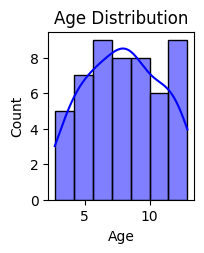

In [22]:
# Plotting Age distribution
plt.subplot(2, 3, 1)
sns.histplot(selected_df_cleaned['Age'], kde=True, color='blue')
plt.title('Age Distribution')


### The chart shows that most individuals are aged 6–10, with fewer very young (3–4) and older (12–13) individuals.

Text(0.5, 1.0, 'Pupil Size Right X Distribution')

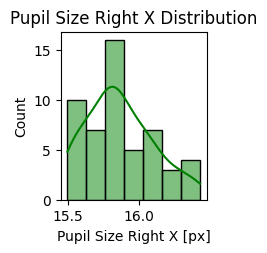

In [23]:
# Plotting Pupil Size Right X distribution
plt.subplot(2, 3, 2)
sns.histplot(selected_df_cleaned['Pupil Size Right X [px]'], kde=True, color='green')
plt.title('Pupil Size Right X Distribution')

Text(0.5, 1.0, 'Correlation Matrix')

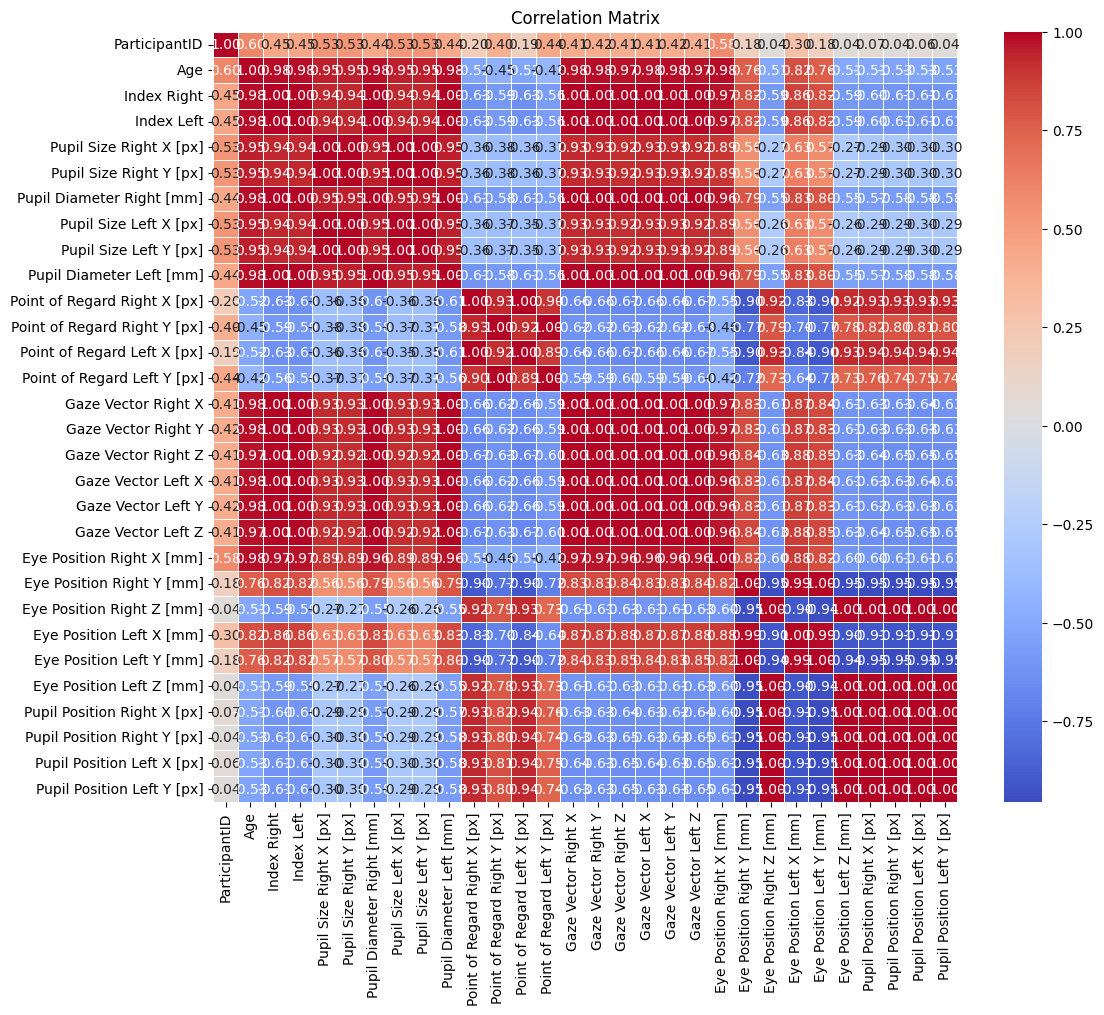

In [24]:
#  Correlation matrix for numerical columns
correlation_matrix_cleaned = numerical_summary_cleaned.corr()
# Visualizing the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')

### The matrix shows strong positive correlations within related eye-tracking features (pupil size, gaze vectors, and eye positions), indicating tightly linked measurements. It also reveals clear negative correlations between opposing directional features, showing how shifts in one dimension inversely affect the others.

C:\Users\1174\AppData\Local\Temp\ipykernel_1976\217760170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=selected_df_cleaned, palette='Set1')


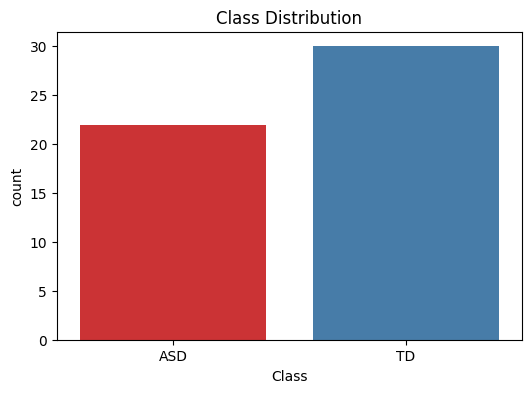

In [25]:
# Displaying the class distribution in a plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=selected_df_cleaned, palette='Set1')
plt.title('Class Distribution')
plt.show()

### The chart shows that the TD class has more samples than the ASD class, with TD being the majority group in the dataset.

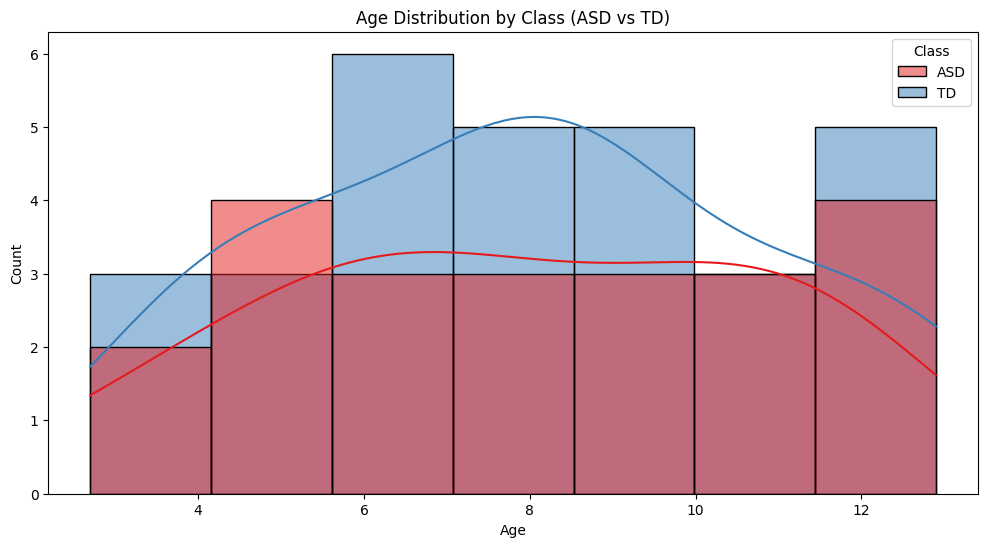

In [26]:
# Plotting Age distribution by Class (ASD vs TD)
plt.figure(figsize=(12, 6))
sns.histplot(data=selected_df_cleaned, x='Age', hue='Class', kde=True, palette='Set1')
plt.title('Age Distribution by Class (ASD vs TD)')
plt.show()

### The age ranges for both ASD and TD groups are similar, with most children clustered between ages 6 and 10. The TD group shows slightly higher counts across several age bins compared to the ASD group.

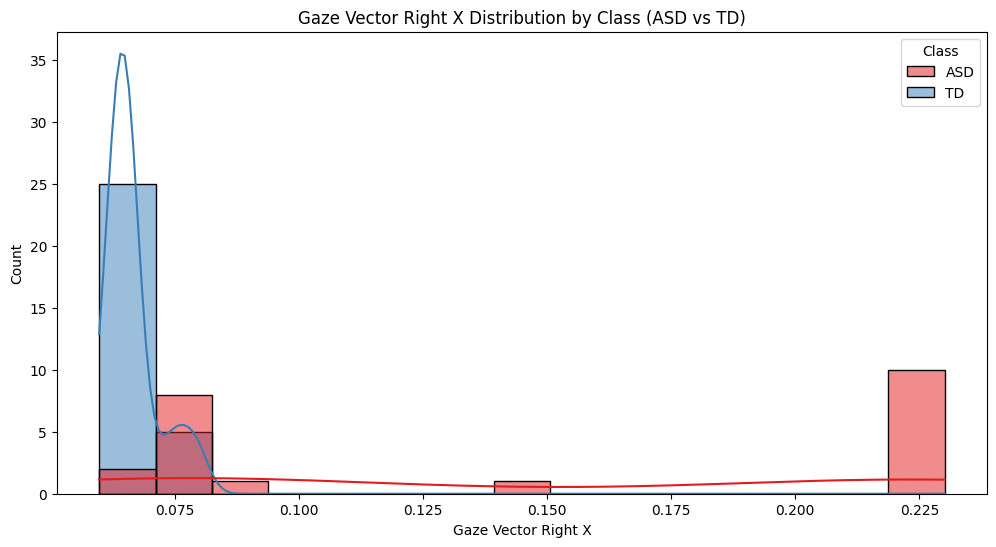

In [27]:
# Plotting Gaze Vector Right X by Class
plt.figure(figsize=(12, 6))
sns.histplot(data=selected_df_cleaned, x='Gaze Vector Right X', hue='Class', kde=True, palette='Set1')
plt.title('Gaze Vector Right X Distribution by Class (ASD vs TD)')
plt.show()

C:\Users\1174\AppData\Local\Temp\ipykernel_1976\2244107350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=selected_df_cleaned, x='Class', y='Age', palette='Set1')


Text(0.5, 1.0, 'Age by Class (ASD vs TD)')

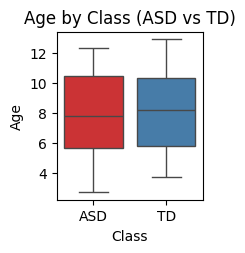

In [28]:
# Boxplot for Age
plt.subplot(2, 3, 1)
sns.boxplot(data=selected_df_cleaned, x='Class', y='Age', palette='Set1')
plt.title('Age by Class (ASD vs TD)')

In [29]:
selected_df_cleaned['Gender'].value_counts()

Gender
M    32
F    20
Name: count, dtype: int64

In [30]:
selected_df_cleaned['Class'].value_counts()

Class
TD     30
ASD    22
Name: count, dtype: int64

In [31]:
selected_df_cleaned['Category Right'].value_counts()


Category Right
Fixation    48
Saccade      4
Name: count, dtype: int64

In [32]:
selected_df_cleaned['Category Left'].value_counts()

Category Left
Fixation    48
Saccade      4
Name: count, dtype: int64

### This code applies label encoding to the categorical columns in the dataset using a LabelEncoder.

In [33]:


# Initialize label encoder
label_encoder = LabelEncoder()

# Apply label encoding to categorical columns

selected_df_cleaned['Gender'] = label_encoder.fit_transform(selected_df_cleaned['Gender'])
selected_df_cleaned['Class'] = label_encoder.fit_transform(selected_df_cleaned['Class'])
selected_df_cleaned['Category Right'] = label_encoder.fit_transform(selected_df_cleaned['Category Right'])
selected_df_cleaned['Category Left'] = label_encoder.fit_transform(selected_df_cleaned['Category Left'])

# Check the info to ensure that encoding was successful
selected_df_cleaned.info()
# Save the label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 7 to 58
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParticipantID                 52 non-null     int64  
 1   Gender                        52 non-null     int64  
 2   Age                           52 non-null     float64
 3   Class                         52 non-null     int64  
 4   Category Right                52 non-null     int64  
 5   Category Left                 52 non-null     int64  
 6   Index Right                   52 non-null     int64  
 7   Index Left                    52 non-null     int64  
 8   Pupil Size Right X [px]       52 non-null     float64
 9   Pupil Size Right Y [px]       52 non-null     float64
 10  Pupil Diameter Right [mm]     52 non-null     float64
 11  Pupil Size Left X [px]        52 non-null     float64
 12  Pupil Size Left Y [px]        52 non-null     float64
 13  Pupil D

['label_encoder.pkl']

In [34]:
selected_df_cleaned['Gender'].value_counts()


Gender
1    32
0    20
Name: count, dtype: int64

In [35]:
selected_df_cleaned['Class'].value_counts()


Class
1    30
0    22
Name: count, dtype: int64

In [36]:
selected_df_cleaned['Category Right'].value_counts()


Category Right
0    48
1     4
Name: count, dtype: int64

In [37]:
selected_df_cleaned['Category Left'].value_counts()

Category Left
0    48
1     4
Name: count, dtype: int64

In [38]:
# Assuming 'selected_df_cleaned' is your original dataframe
n_needed = 1000 - len(selected_df_cleaned)

# Randomly sample the data with replacement
bootstrap_df = selected_df_cleaned.sample(n=n_needed, replace=True, random_state=42)

# Concatenate the original dataframe with the resampled data
augmented_df = pd.concat([selected_df_cleaned, bootstrap_df], ignore_index=True)

# Check the new shape
print(augmented_df.shape)  

(1000, 34)


In [39]:
augmented_df['Class'].value_counts()

Class
1    600
0    400
Name: count, dtype: int64

In [40]:
augmented_df.tail()

,ParticipantID,Gender,Age,Class,Category Right,Category Left,Index Right,Index Left,Pupil Size Right X [px],Pupil Size Right Y [px],Pupil Diameter Right [mm],Pupil Size Left X [px],Pupil Size Left Y [px],Pupil Diameter Left [mm],Point of Regard Right X [px],Point of Regard Right Y [px],Point of Regard Left X [px],Point of Regard Left Y [px],Gaze Vector Right X,Gaze Vector Right Y,Gaze Vector Right Z,Gaze Vector Left X,Gaze Vector Left Y,Gaze Vector Left Z,Eye Position Right X [mm],Eye Position Right Y [mm],Eye Position Right Z [mm],Eye Position Left X [mm],Eye Position Left Y [mm],Eye Position Left Z [mm],Pupil Position Right X [px],Pupil Position Right Y [px],Pupil Position Left X [px],Pupil Position Left Y [px]
995,35,1,4.2,1,1,1,2,2,15.5745,15.5745,3.4746,15.7740,15.7740,3.5517,663.1569,494.5760,661.0360,453.3500,0.0672,0.3605,-0.9303,0.0890,0.3741,-0.9231,0.5814,-75.9172,530.2545,-47.2384,-73.5922,534.5239,635.3886,846.9611,849.4998,833.5068
996,49,0,12.3,1,0,0,3,3,15.8301,15.8301,3.4415,15.9072,15.9072,3.5201,642.2008,372.5182,655.9556,320.5839,0.0667,0.4257,-0.9024,0.1035,0.4329,-0.8955,-0.0916,-74.6925,526.9567,-48.6408,-72.2021,531.6119,638.4364,841.9617,856.6114,827.6304
997,29,1,4.2,0,0,0,2,2,15.7612,15.7612,3.5017,16.0814,16.0814,3.5804,668.7859,619.1078,667.2991,578.5450,0.0771,0.3012,-0.9504,0.1060,0.3174,-0.9423,0.4224,-77.4422,531.2422,-47.2770,-75.5287,534.2505,635.8985,854.5907,849.4475,843.6700
998,28,1,11.8,0,0,0,2,2,15.8214,15.8214,3.5075,16.1280,16.1280,3.5809,669.1008,619.7364,667.8441,577.7171,0.0767,0.3006,-0.9507,0.1077,0.3216,-0.9407,0.6050,-77.7722,531.1697,-47.0734,-75.9156,534.1877,635.0818,856.1423,848.5166,845.3497
999,13,1,5.4,0,0,0,1,1,16.0490,16.0490,3.5854,16.4514,16.4514,3.6988,1000.3339,872.3518,991.7447,848.1982,0.2223,0.1784,-0.9585,0.2386,0.1909,-0.9522,10.5845,-80.3221,525.6380,-36.3928,-76.8316,527.7724,586.2399,874.1788,799.6540,856.5352


In [41]:
# List of features to display
features_columns = [
    'Point of Regard Right X [px]', 'Eye Position Left Y [mm]', 'Pupil Diameter Right [mm]', 
    'Eye Position Right Y [mm]', 'Pupil Diameter Left [mm]', 'Pupil Position Right Y [px]', 
    'Pupil Position Left Y [px]', 'Point of Regard Right Y [px]', 'Pupil Size Left Y [px]', 
    'Eye Position Left X [mm]', 'Point of Regard Left Y [px]', 'Pupil Size Left X [px]', 
    'Pupil Position Left X [px]', 'Point of Regard Left X [px]', 'Pupil Position Right X [px]', 
    'Gaze Vector Right Y', 'Index Right', 'Eye Position Right X [mm]', 'Index Left', 'Gaze Vector Left Y'
]

# Filter the DataFrame for rows where Class == 0 (ASD)
asD_rows = augmented_df[augmented_df['Class'] == 0]

# Display the first 5 rows of the selected features
first_five_asd_rows = asD_rows[features_columns].head(5)
print(first_five_asd_rows)


   Point of Regard Right X [px]  Eye Position Left Y [mm]  \
0                     1000.4943                  -75.9572   
1                     1000.7899                  -76.3415   
2                     1001.6729                  -76.5310   
3                     1001.5989                  -76.5670   
4                     1001.3208                  -76.7364   

   Pupil Diameter Right [mm]  Eye Position Right Y [mm]  \
0                     3.6724                   -79.4046   
1                     3.6507                   -79.7108   
2                     3.6311                   -80.0119   
3                     3.6114                   -80.0545   
4                     3.6027                   -80.3244   

   Pupil Diameter Left [mm]  Pupil Position Right Y [px]  \
0                    3.7859                     875.4003   
1                    3.7696                     875.3341   
2                    3.7521                     875.1355   
3                    3.7282           

In [42]:
# List of features to display
features_columns = [
    'Point of Regard Right X [px]', 'Eye Position Left Y [mm]', 'Pupil Diameter Right [mm]', 
    'Eye Position Right Y [mm]', 'Pupil Diameter Left [mm]', 'Pupil Position Right Y [px]', 
    'Pupil Position Left Y [px]', 'Point of Regard Right Y [px]', 'Pupil Size Left Y [px]', 
    'Eye Position Left X [mm]', 'Point of Regard Left Y [px]', 'Pupil Size Left X [px]', 
    'Pupil Position Left X [px]', 'Point of Regard Left X [px]', 'Pupil Position Right X [px]', 
    'Gaze Vector Right Y', 'Index Right', 'Eye Position Right X [mm]', 'Index Left', 'Gaze Vector Left Y'
]

# Filter the DataFrame for rows where Class == 1 (TD)
asD_rows = augmented_df[augmented_df['Class'] == 1]

# Display the first 5 rows of the selected features
first_five_asd_rows = asD_rows[features_columns].head(5)
print(first_five_asd_rows)


    Point of Regard Right X [px]  Eye Position Left Y [mm]  \
22                      667.8181                  -75.1661   
23                      667.8501                  -74.7746   
24                      666.3342                  -74.4662   
25                      666.8191                  -74.1751   
26                      666.3679                  -73.9615   

    Pupil Diameter Right [mm]  Eye Position Right Y [mm]  \
22                     3.5004                   -77.0980   
23                     3.4959                   -76.7771   
24                     3.4890                   -76.4342   
25                     3.4873                   -76.3503   
26                     3.4851                   -76.2143   

    Pupil Diameter Left [mm]  Pupil Position Right Y [px]  \
22                    3.5706                     853.0647   
23                    3.5684                     851.7951   
24                    3.5653                     850.7080   
25                    

### # Split the data into features (X) and target (Y)
### This code separates the dataset into feature variables by dropping ParticipantID and Class, and assigns Class as the target variable.

In [43]:
# Split the data into features (X) and target (Y)
X = augmented_df.drop(columns=['ParticipantID', 'Class'])  # Drop ParticipantID and Class columns from features
Y = augmented_df['Class']  # Target variable (Class)


### # Perform train-test split (80% training, 20% testing)

In [44]:


# Perform train-test split (80% training, 20% testing)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Display the shape of the resulting datasets
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((800, 32), (200, 32), (800,), (200,))

### This code trains a Random Forest model and extracts, sorts, and displays the top most important features based on their importance scores.


In [45]:
# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame to display feature names with their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the sorted features by importance
print("\nFeature importances:")
print(feature_importance_df)

# Select the top N important features (you can adjust this number)
top_n = 20  # You can change this to 10, 15, 20, etc.
top_n_features = feature_importance_df.head(top_n)['Feature'].tolist()
top_features_indices = feature_importance_df.head(top_n).index

# Create a dictionary of top features and their importance scores
feature_info = {
    'selected_features': top_n_features,
    'feature_importance': dict(zip(top_n_features, feature_importance_df.loc[feature_importance_df['Feature'].isin(top_n_features), 'Importance']))
}

# Save the feature information as a pickle file
with open('feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print("Feature selection information saved successfully!")

# Filter the training and test sets to only use the selected features
X_train_selected = X_train[top_n_features]
X_test_selected = X_test[top_n_features]



Feature importances:
                         Feature  Importance
12  Point of Regard Right X [px]    0.123558
26      Eye Position Left Y [mm]    0.121405
8      Pupil Diameter Right [mm]    0.120550
23     Eye Position Right Y [mm]    0.113595
11      Pupil Diameter Left [mm]    0.112039
29   Pupil Position Right Y [px]    0.096435
31    Pupil Position Left Y [px]    0.092055
13  Point of Regard Right Y [px]    0.065587
10        Pupil Size Left Y [px]    0.035214
25      Eye Position Left X [mm]    0.034642
15   Point of Regard Left Y [px]    0.018842
9         Pupil Size Left X [px]    0.018830
30    Pupil Position Left X [px]    0.018244
14   Point of Regard Left X [px]    0.008979
28   Pupil Position Right X [px]    0.007945
17           Gaze Vector Right Y    0.006642
4                    Index Right    0.001963
22     Eye Position Right X [mm]    0.001394
5                     Index Left    0.000708
20            Gaze Vector Left Y    0.000613
24     Eye Position Right Z [mm] 

In [46]:
X_train_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 29 to 102
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Point of Regard Right X [px]  800 non-null    float64
 1   Eye Position Left Y [mm]      800 non-null    float64
 2   Pupil Diameter Right [mm]     800 non-null    float64
 3   Eye Position Right Y [mm]     800 non-null    float64
 4   Pupil Diameter Left [mm]      800 non-null    float64
 5   Pupil Position Right Y [px]   800 non-null    float64
 6   Pupil Position Left Y [px]    800 non-null    float64
 7   Point of Regard Right Y [px]  800 non-null    float64
 8   Pupil Size Left Y [px]        800 non-null    float64
 9   Eye Position Left X [mm]      800 non-null    float64
 10  Point of Regard Left Y [px]   800 non-null    float64
 11  Pupil Size Left X [px]        800 non-null    float64
 12  Pupil Position Left X [px]    800 non-null    float64
 13  Point of 

In [47]:
X_test_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 521 to 78
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Point of Regard Right X [px]  200 non-null    float64
 1   Eye Position Left Y [mm]      200 non-null    float64
 2   Pupil Diameter Right [mm]     200 non-null    float64
 3   Eye Position Right Y [mm]     200 non-null    float64
 4   Pupil Diameter Left [mm]      200 non-null    float64
 5   Pupil Position Right Y [px]   200 non-null    float64
 6   Pupil Position Left Y [px]    200 non-null    float64
 7   Point of Regard Right Y [px]  200 non-null    float64
 8   Pupil Size Left Y [px]        200 non-null    float64
 9   Eye Position Left X [mm]      200 non-null    float64
 10  Point of Regard Left Y [px]   200 non-null    float64
 11  Pupil Size Left X [px]        200 non-null    float64
 12  Pupil Position Left X [px]    200 non-null    float64
 13  Point of 

In [48]:
X_test_selected.columns

Index(['Point of Regard Right X [px]', 'Eye Position Left Y [mm]',
       'Pupil Diameter Right [mm]', 'Eye Position Right Y [mm]',
       'Pupil Diameter Left [mm]', 'Pupil Position Right Y [px]',
       'Pupil Position Left Y [px]', 'Point of Regard Right Y [px]',
       'Pupil Size Left Y [px]', 'Eye Position Left X [mm]',
       'Point of Regard Left Y [px]', 'Pupil Size Left X [px]',
       'Pupil Position Left X [px]', 'Point of Regard Left X [px]',
       'Pupil Position Right X [px]', 'Gaze Vector Right Y', 'Index Right',
       'Eye Position Right X [mm]', 'Index Left', 'Gaze Vector Left Y'],
      dtype='object')

In [49]:
X_train_selected.columns

Index(['Point of Regard Right X [px]', 'Eye Position Left Y [mm]',
       'Pupil Diameter Right [mm]', 'Eye Position Right Y [mm]',
       'Pupil Diameter Left [mm]', 'Pupil Position Right Y [px]',
       'Pupil Position Left Y [px]', 'Point of Regard Right Y [px]',
       'Pupil Size Left Y [px]', 'Eye Position Left X [mm]',
       'Point of Regard Left Y [px]', 'Pupil Size Left X [px]',
       'Pupil Position Left X [px]', 'Point of Regard Left X [px]',
       'Pupil Position Right X [px]', 'Gaze Vector Right Y', 'Index Right',
       'Eye Position Right X [mm]', 'Index Left', 'Gaze Vector Left Y'],
      dtype='object')

### This code scales the selected top features using StandardScaler and converts the transformed results back into DataFrames for training and testing.


In [50]:
# Apply StandardScaler to the selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Convert the scaled data back into DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=top_n_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=top_n_features)
# Save the scaler
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

# *Model Training*

SVM Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00       120

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 80   0]
 [  0 120]]


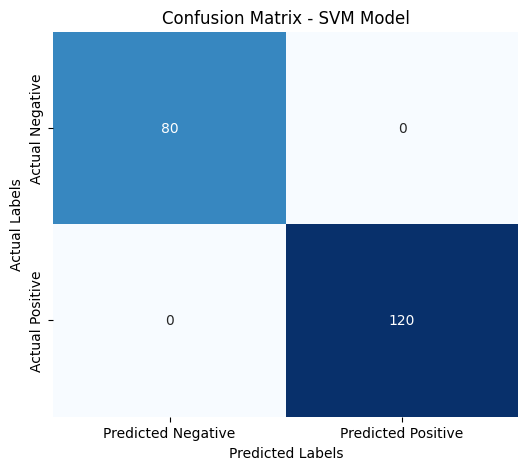

SVM model saved successfully!


In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Support Vector Machine (SVM) model
svm_model = SVC(random_state=42)

# Train the model using the scaled training data
svm_model.fit(X_train_scaled_df, Y_train)

# Make predictions on the test data
Y_pred = svm_model.predict(X_test_scaled_df)

# Evaluate the model's performance
accuracy = accuracy_score(Y_test, Y_pred)
print(f"SVM Model Accuracy: {accuracy * 100:.2f}%")

# Display the classification report for detailed performance metrics
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
# Compute the confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Define the model name
model_name = "SVM Model"

# Create the heatmap for the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

# Show the plot
plt.show()
# Save the trained SVM model
joblib.dump(svm_model, 'svm_model.pkl')

print("SVM model saved successfully!")

Random Forest Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00       120

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 80   0]
 [  0 120]]


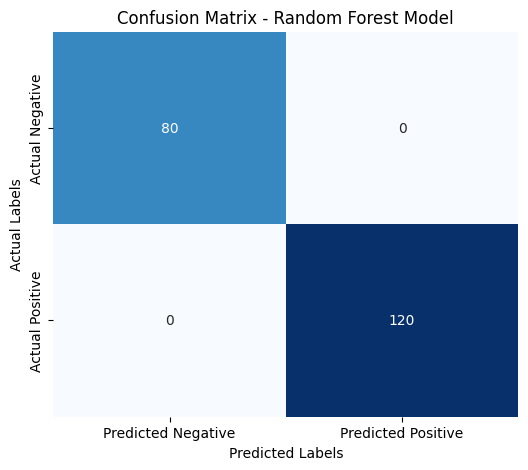

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the RandomForestClassifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the scaled training data
rf_model.fit(X_train_scaled_df, Y_train)

# Make predictions on the test data
Y_pred_rf = rf_model.predict(X_test_scaled_df)

# Evaluate the model's performance
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf * 100:.2f}%")

# Display the classification report for detailed performance metrics
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_rf))

print(confusion_matrix(Y_test, Y_pred_rf))
# Generate the confusion matrix
cm_rf = confusion_matrix(Y_test, Y_pred_rf)

# Define the model name
model_name_rf = "Random Forest Model"

# Create the heatmap for the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title(f'Confusion Matrix - {model_name_rf}')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

# Show the plot
plt.show()

Epoch 1/10


C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9900 - loss: 0.0788 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.0620e-04 - val_accuracy: 1.0000 - val_loss: 6.5529e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 3.0016e-04 - val_accuracy: 1.0000 - val_loss: 3.4627e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.0154e-04 - val_accuracy: 1.0000 - val_loss: 2.5886e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.2061e-04 - val_accuracy: 1.0000 - val_loss: 1.9673e-04
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 8.3689e-05 - val_accuracy: 1.0000 - val_loss: 1.2526e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - lo

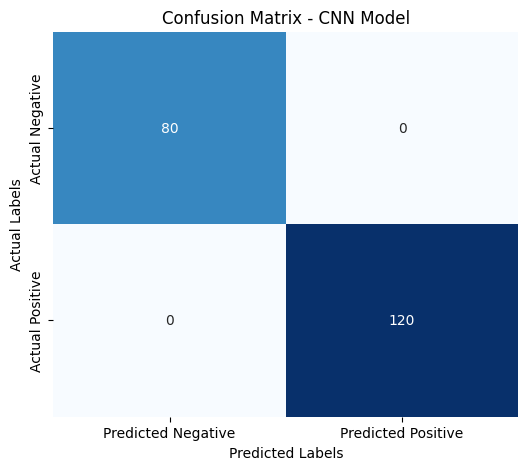

In [53]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report

# Reshape data for CNN (1D Convolutional Network)
# CNNs expect input to be in the form of (samples, time_steps, features)
X_train_cnn = X_train_scaled_df.values.reshape(X_train_scaled_df.shape[0], X_train_scaled_df.shape[1], 1)
X_test_cnn = X_test_scaled_df.values.reshape(X_test_scaled_df.shape[0], X_test_scaled_df.shape[1], 1)

# Define the CNN model
cnn_model = Sequential()

# Add a 1D convolutional layer
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=2))

# Add another convolutional layer
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the data for the dense layers
cnn_model.add(Flatten())

# Add a fully connected (dense) layer
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))  # Use 'sigmoid' for binary classification (ASD vs TD)

# Compile the model
cnn_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
cnn_model.fit(X_train_cnn, Y_train, epochs=10, batch_size=8, validation_data=(X_test_cnn, Y_test))

# Evaluate the model
Y_pred_cnn = cnn_model.predict(X_test_cnn)
Y_pred_cnn = (Y_pred_cnn > 0.5).astype(int)  # Convert probabilities to binary class labels

# Evaluate the performance
accuracy_cnn = accuracy_score(Y_test, Y_pred_cnn)
print(f"CNN Model Accuracy: {accuracy_cnn * 100:.2f}%")

# Display the classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_cnn))
print(confusion_matrix(Y_test, Y_pred_cnn))
# Generate the confusion matrix
cm_cnn = confusion_matrix(Y_test, Y_pred_cnn)

# Define the model name
model_name_cnn = "CNN Model"

# Create the heatmap for the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title(f'Confusion Matrix - {model_name_cnn}')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

# Show the plot
plt.show()

AdaBoost Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00       120

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

[[ 80   0]
 [  0 120]]


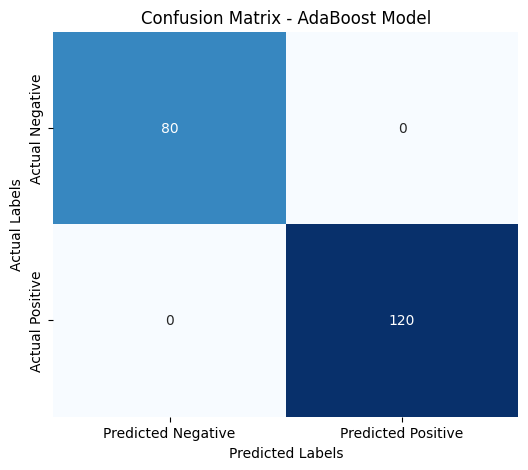

In [54]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the AdaBoost model (DecisionTreeClassifier is the default base estimator)
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# Train the AdaBoost model using the training data
adaboost_model.fit(X_train_selected, Y_train)

# Make predictions on the test data
Y_pred_adaboost = adaboost_model.predict(X_test_selected)

# Evaluate the model's performance
accuracy_adaboost = accuracy_score(Y_test, Y_pred_adaboost)
print(f"AdaBoost Model Accuracy: {accuracy_adaboost * 100:.2f}%")

# Display the classification report for detailed performance metrics
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_adaboost))
print(confusion_matrix(Y_test, Y_pred_adaboost))

# Generate the confusion matrix
cm_adaboost = confusion_matrix(Y_test, Y_pred_adaboost)

# Define the model name
model_name_adaboost = "AdaBoost Model"

# Create the heatmap for the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_adaboost, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title(f'Confusion Matrix - {model_name_adaboost}')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

# Show the plot
plt.show()

In [55]:
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# First row data (example values from your input, 20 features in total)
first_row = np.array([
    667.8181, -75.1661, 3.5004, -77.0980, 3.5706, 853.0647, 841.8229, 617.2812, 
    15.8452, -47.4015, 575.8643, 15.8452, 849.8674, 666.8105, 636.2259, 0.3022, 
    0.3417, 2, 0.3233, 0.3233  # 20th feature assumed to be the same as 19th for simplicity
])

# Reshape the data to match the input format for the model (1 sample with 20 features)
first_row = first_row.reshape(1, -1)

# Load the pre-trained SVM model (after training it on your scaled data)
svm_model = joblib.load('svm_model.pkl')

# Load the same scaler used for training
scaler = joblib.load('scaler.pkl')  # Assuming you saved the scaler during training

# Scale the input data using the same scaler used for training
first_row_scaled = scaler.transform(first_row)

# Make the prediction using the trained model
prediction = svm_model.predict(first_row_scaled)

# Output interpretation based on class
if prediction == 0:
    print("Predicted class: 0 (ASD)")  # Class 0 = ASD
else:
    print("Predicted class: 1 (TD)")   # Class 1 = TD



Predicted class: 1 (TD)


C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [56]:
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler

# First row data (20 features from your provided input)
first_row = np.array([
    1000.4943, -75.9572, 3.6724, -79.4046, 3.7859, 875.4003, 854.7313, 878.9070, 
    16.7667, -32.1234, 859.2012, 16.7667, 781.0393, 996.9665, 567.2759, 1, 0.1737, 
    14.5130, 1, 0.1855  # Assuming the 20th feature is Gaze Vector Left Y (0.1855)
])

# Reshape the data to match the input format for the model (1 sample with 20 features)
first_row = first_row.reshape(1, -1)

# Load the pre-trained SVM model (after training it on your scaled data)
svm_model = joblib.load('svm_model.pkl')

# Load the same scaler used for training (assuming you saved the scaler during training)
scaler = joblib.load('scaler.pkl')  # Make sure to save and load the scaler

# Scale the input data using the same scaler used for training
first_row_scaled = scaler.transform(first_row)

# Make the prediction using the trained model
prediction = svm_model.predict(first_row_scaled)

# Output interpretation based on class
if prediction == 0:
    print("Predicted class: 0 (ASD)")  # Class 0 = ASD
else:
    print("Predicted class: 1 (TD)")   # Class 1 = TD


Predicted class: 0 (ASD)


C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
